In [5]:
import kagglehub
import pandas as pd
import os

# 1. Descarga el dataset
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")
archivo_csv = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, archivo_csv)
df = pd.read_csv(full_path)
pd.set_option('display.max_columns', None)

In [11]:
#PART 1
print("Columns:", df.columns.tolist())
df.columns = df.columns.str.strip() #clean the columns
col_b = [c for c in df.columns if 'category' in c.lower()][0] #columns to be used
table_crosstab = pd.crosstab(df[col_b], df['isBestSeller']) #create the tabñe
proportion_bs = (table_crosstab[True] / table_crosstab.sum(axis=1)).sort_values(ascending=False) #calculate prop

print("\nCategories with more most sellers:")
print(proportion_bs.head(10))

Columns: ['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']

Categories with more most sellers:
category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
dtype: float64


In [13]:
#PART 2
from scipy.stats import chi2_contingency
import numpy as np

chi2, p_val, dof, expected = chi2_contingency(table_crosstab) #chi 2 
#calculate cramer v
n = table_crosstab.sum().sum()  # size
min_dim = min(table_crosstab.shape) - 1 
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Chi-2: {chi2:.2f}")
print(f"P-Value:           {p_val:.4e}")
print(f"Cramér's V:         {cramers_v:.4f}")

Chi-2: 36540.20
P-Value:           0.0000e+00
Cramér's V:         0.1223


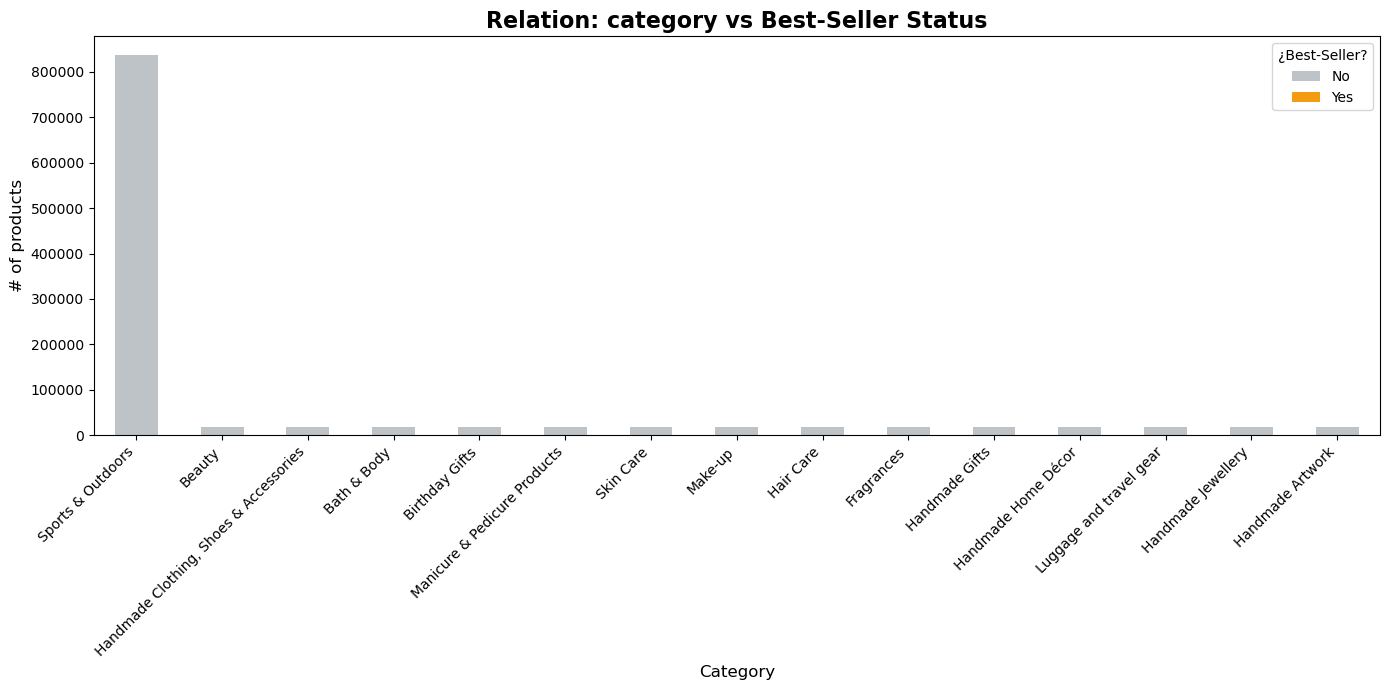

In [14]:
#PART 3
import matplotlib.pyplot as plt

col_category = [c for c in df.columns if 'category' in c.lower()][0] #check the columns to be used
top_15_categories = df[col_category].value_counts().head(15).index #select the top15
ct_filtered = table_crosstab.loc[top_15_categories] #filter

ax = ct_filtered.plot(kind='bar', 
                      stacked=True, 
                      figsize=(14, 7), 
                      color=['#bdc3c7', '#f39c12']) 

plt.title(f'Relation: {col_categoria} vs Best-Seller Status', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('# of products', fontsize=12)
plt.legend(title='¿Best-Seller?', labels=['No', 'Yes'], loc='upper right')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [17]:
#PART 0
col_price = [c for c in df.columns if 'price' in c.lower()][0]
#calculate quartiles
Q1 = df[col_price].quantile(0.25) 
Q3 = df[col_price].quantile(0.75)
IQR = Q3 - Q1
# Define the limits
limit_i = Q1 - 1.5 * IQR
limit_s = Q3 + 1.5 * IQR
# Filter
df_clean = df[(df[col_price] >= limit_i) & (df[col_price] <= limit_s)]

print(f"Lower Limit: {limit_i:.2f}")
print(f"Upper Limit: {limit_s:.2f}")

Lower Limit: -44.01
Upper Limit: 99.99


C:\Users\punk_\AppData\Local\Temp\ipykernel_18796\1689162018.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top20, x=col_cat, y=col_precio, palette="muted")


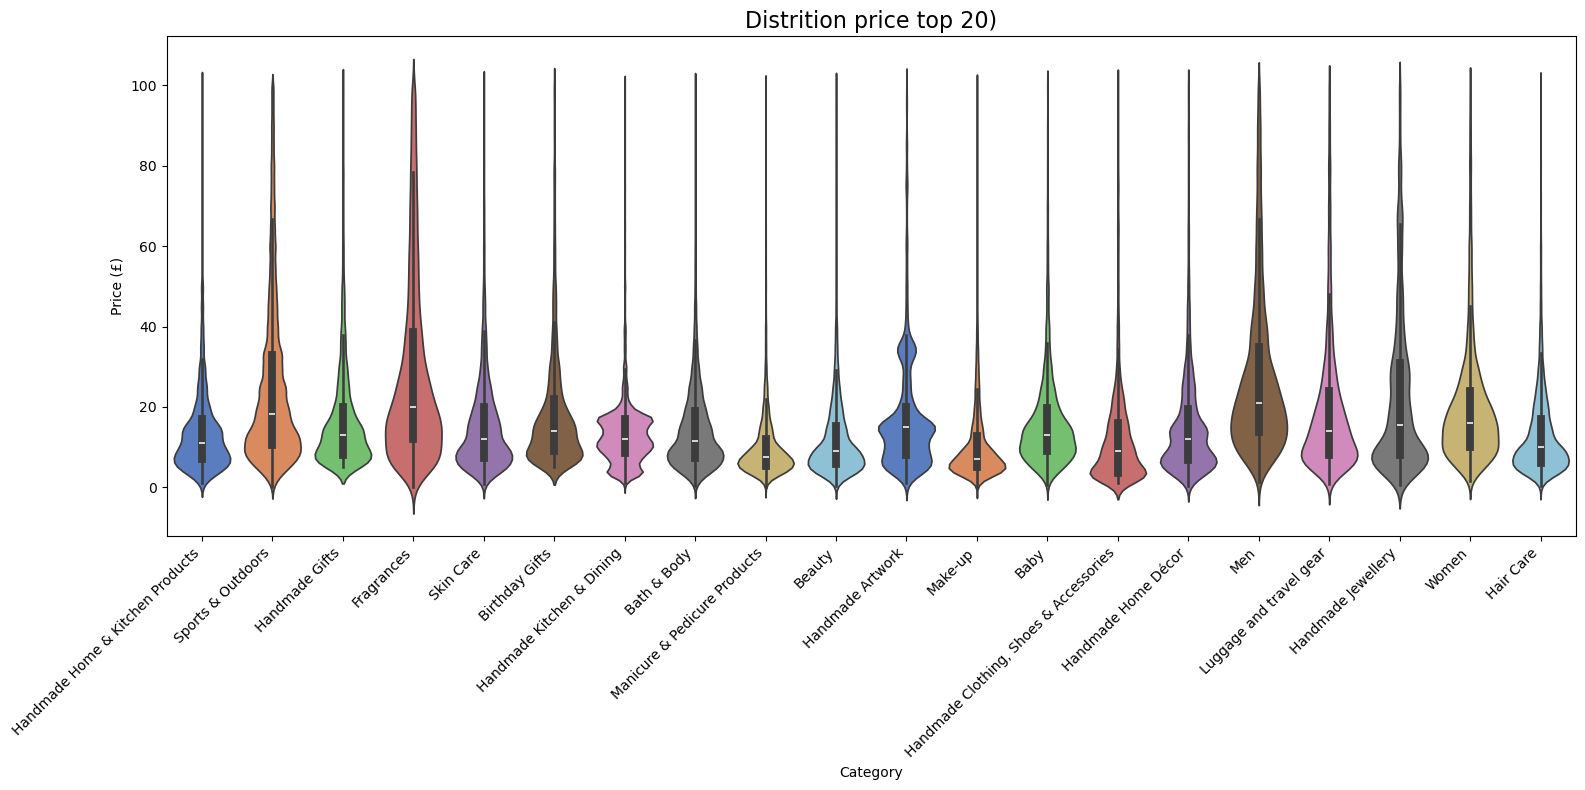

In [19]:
#PART 1
import seaborn as sns
import matplotlib.pyplot as plt

#identify columns
col_price = [c for c in df_clean.columns if 'price' in c.lower()][0]
col_cat = [c for c in df_clean.columns if 'category' in c.lower()][0]

# filter top 20
top_20_cats = df_clean[col_cat].value_counts().head(20).index
df_top20 = df_clean[df_clean[col_cat].isin(top_20_cats)]

# Create the violin
plt.figure(figsize=(16, 8))
sns.violinplot(data=df_top20, x=col_cat, y=col_precio, palette="muted")
plt.title('Distrition price top 20)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Category')
plt.ylabel('Price (£)')
plt.tight_layout()
plt.show()

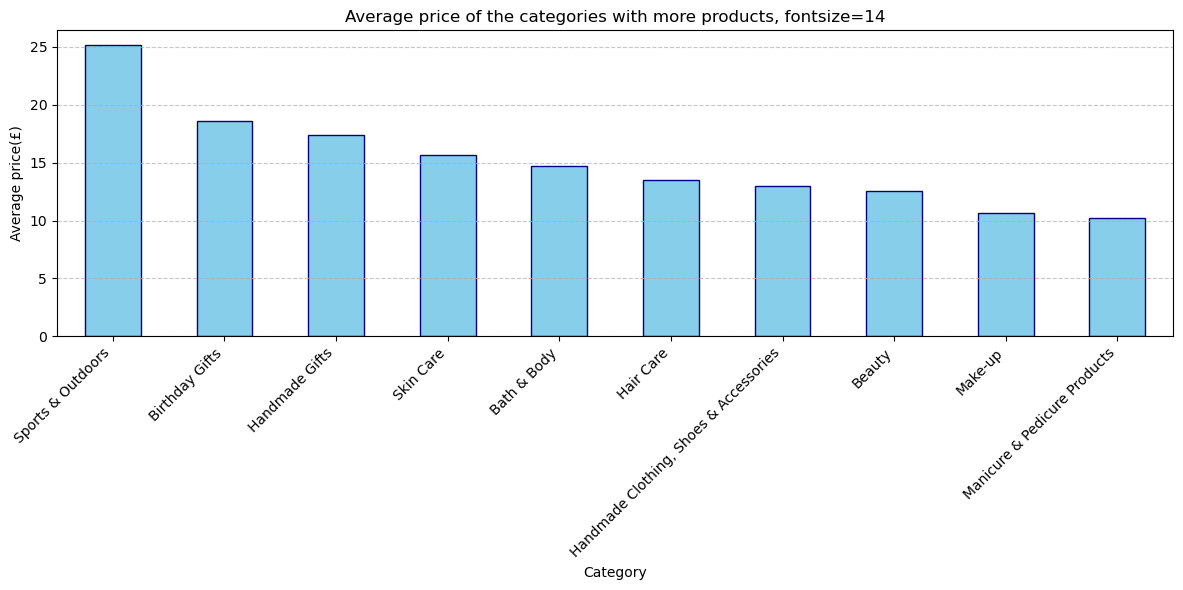

In [22]:
#PART 2
import matplotlib.pyplot as plt
#identify coluns
col_price = [c for c in df_clean.columns if 'price' in c.lower()][0]
col_cat = [c for c in df_clean.columns if 'category' in c.lower()][0]
#top 10 of products
top_10_count_cats = df_clean[col_cat].value_counts().head(10).index
#filter and get the averafge
df_top10_avg = df_clean[df_clean[col_cat].isin(top_10_count_cats)]
avg_prices_top10 = df_top10_avg.groupby(col_cat)[col_precio].mean().sort_values(ascending=False)
#create the bartchart
plt.figure(figsize=(12, 6))
avg_prices_top10.plot(kind='bar', color='skyblue', edgecolor='navy')
plt.title('Average price of the categories with more products, fontsize=14')
plt.xlabel('Category')
plt.ylabel('Average price(£)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\punk_\AppData\Local\Temp\ipykernel_18796\167630924.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10_ratings, x=col_cat, y=col_rating, palette="Set3")


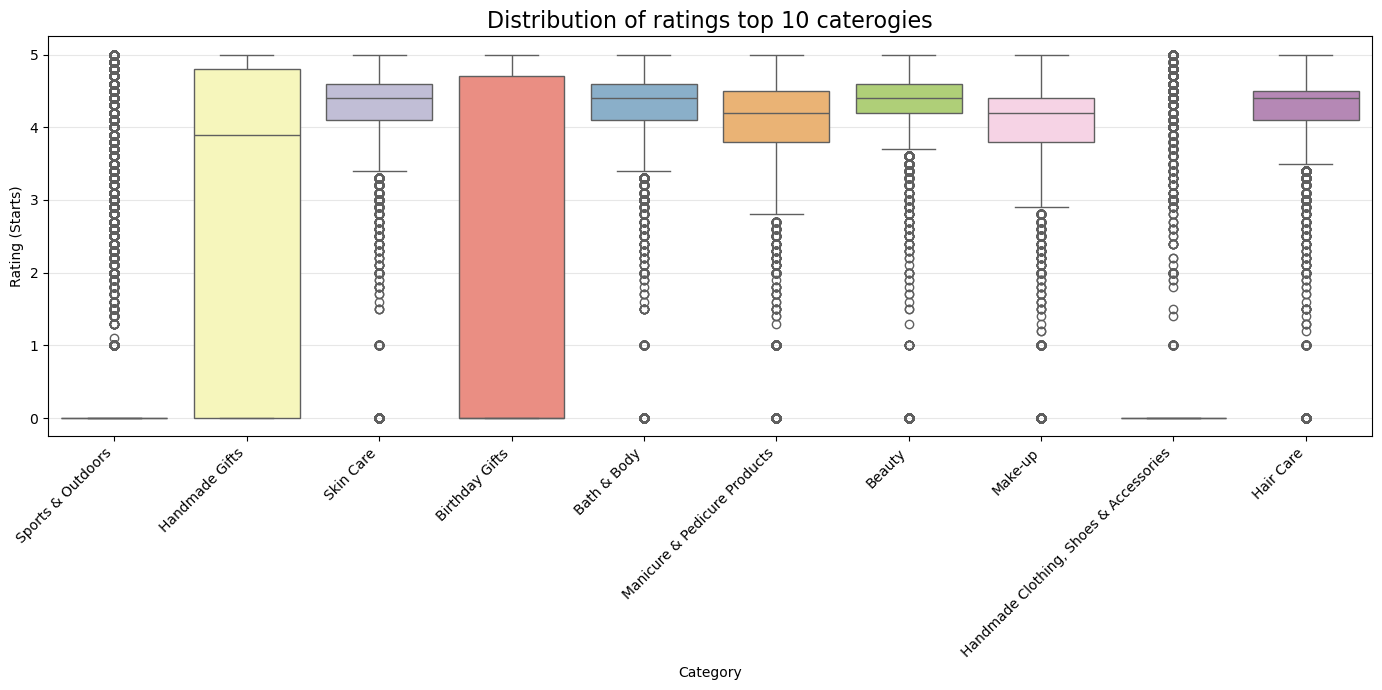

In [24]:
#PART 3
import seaborn as sns
import matplotlib.pyplot as plt
col_rating = [c for c in df_clean.columns if 'star' in c.lower() or 'rating' in c.lower()][0]
col_cat = [c for c in df_clean.columns if 'category' in c.lower()][0]
#Filter top 10
top_10_cats = df_clean[col_cat].value_counts().head(10).index
df_top10_ratings = df_clean[df_clean[col_cat].isin(top_10_cats)]
#create boxplot
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top10_ratings, x=col_cat, y=col_rating, palette="Set3")
plt.title('Distribution of ratings top 10 caterogies', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Category')
plt.ylabel('Rating (Starts)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Part 3: Investigating the Interplay Between Product Prices and Ratings
Objective: Analyze how product ratings (stars) correlate with product prices.

1. Correlation Coefficients:

Calculate the correlation coefficient between price and stars.
Is there a significant correlation between product price and its rating?
2. Visualizations:

Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
Use a correlation heatmap to visualize correlations between all numerical variables.
Examine if product prices typically follow a normal distribution using a QQ plot.


In [27]:
#PART 1
col_price = [c for c in df_clean.columns if 'price' in c.lower()][0]
col_rating = [c for c in df_clean.columns if 'star' in c.lower() or 'rating' in c.lower()][0]
# calculate the correlation
correlacion = df_clean[col_precio].corr(df_clean[col_rating])
print(f"Correlation coefficient between {col_precio} and {col_rating}: {correlacion:.4f}")

Correlation coefficient between price and stars: -0.0777


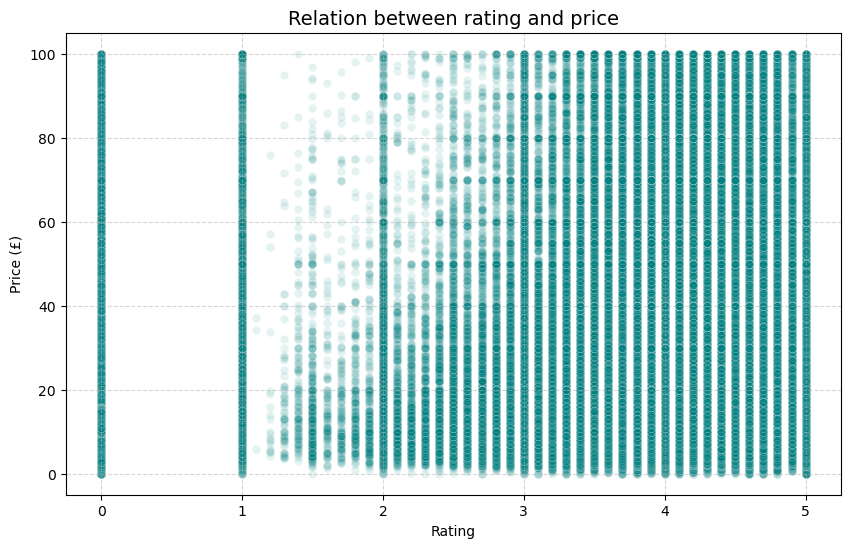

In [29]:
#PART 2
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x=col_rating, y=col_price, alpha=0.1, color='teal')
plt.title('Relation between rating and price', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Price (£)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()